# Open exploration

To obtain a better understanding of the dike model, an open exploration has been conducted. There are different problem formulations for the dike model and problem formulation 2 was chosen, as was discussed during the first policy debate with all stakeholders. This problem formulation is also most relevant for the Environmental Interest Group, since it focuses on the sum of outcomes over all the dike rings, instead of looking at all dike rings separately. The outcomes are:
* Expected annual damage
* Dike investment costs
* RfR investment costs
* Evacuation costs
* Expected number of deaths

Four policy options are examined in the open exploration:
1. A baseline with no action (*Base case*)
2. Increasing dike height by 5 dm at every location and decision step (*Dikes only*)
3. Implementing RfR at every location and decision step (*RfR only*)
4. The policy proposed during the final debate: dike heightening at locations A3, A4 and A5 (5 dm), implementing RfR at A2, A3 and A5 all at time step 0. Additionally, the final policy includes a warning system for evacuations which will give a warning 3 days in advance of a threat. (*Final policy*)

The experiments are performed using the four policies and 1000 scenarios. These results are plotted and saved, and they form the basis for the multi-scenario MORDM.
A traditional multi-scenario MORDM uses the results of a single scenario MORDM to create new scenarios for which the multi-scenario MORDM is performed. Due to computational issues and some time constraints it was decided to make an adapted multi-scenario MORDM. The scenarios are based on the open exploration instead of the outcomes of a single scenario MORDM.

From the open exploration a best case and a worst case scenario are saved. The best case scenario from the perspective of the Environmental Interest Group is a lot of Room for the River projects and few casualties. Therefore, the scenario that resulted in the lowest expected number of deaths for the policy ‘RfR only’ was chosen as the best case scenario. The Environmental Interest Group is opposed to dike heightening. The scenario with ‘Dikes only’ and the highest expected number of deaths was therefore chosen as the worst case scenario. These scenarios are used in the file Multi_scenario_MORDM.ipynb.


In [11]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from ema_workbench import (Policy, ema_logging, MultiprocessingEvaluator, save_results, load_results)
from problem_formulation import get_model_for_problem_formulation


In [12]:
# make sure pandas is version 1.0 or higher
# make sure networkx is version 2.4 or higher
print(pd.__version__)
print(nx.__version__)

2.2.3
3.4.2


In [13]:
ema_logging.log_to_stderr(ema_logging.INFO)

# Select problem formulation 2
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [14]:
def get_do_nothing_dict():
    return {l.name:0 for l in dike_model.levers}

# Define 4 policies
policies = [

    # Base case is not implementing anything
    Policy("Base case", **{l.name: 0 for l in dike_model.levers}),

    # Increase dike height with 5 dm every decision step
    Policy("Dikes only", **dict(get_do_nothing_dict(), **{
        'A.1_DikeIncrease 0': 5, 'A.1_DikeIncrease 1': 5, 'A.1_DikeIncrease 2': 5,
        'A.2_DikeIncrease 0': 5, 'A.2_DikeIncrease 1': 5, 'A.2_DikeIncrease 2': 5,
        'A.3_DikeIncrease 0': 5, 'A.3_DikeIncrease 1': 5, 'A.3_DikeIncrease 2': 5,
        'A.4_DikeIncrease 0': 5, 'A.4_DikeIncrease 1': 5, 'A.4_DikeIncrease 2': 5,
        'A.5_DikeIncrease 0': 5, 'A.5_DikeIncrease 1': 5, 'A.5_DikeIncrease 2': 5
    })),

    # Implement RfR on all locations at all decision steps
    Policy("RfR only", **dict(get_do_nothing_dict(), **{
        '0_RfR 0': 1, '0_RfR 1': 1, '0_RfR 2': 1,
        '1_RfR 0': 1, '1_RfR 1': 1, '1_RfR 2': 1,
        '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1,
        '3_RfR 0': 1, '3_RfR 1': 1, '3_RfR 2': 1,
        '4_RfR 0': 1, '4_RfR 1': 1, '4_RfR 2': 1,
        '5_RfR 0': 1, '5_RfR 1': 1, '5_RfR 2': 1,
        '6_RfR 0': 1, '6_RfR 1': 1, '6_RfR 2': 1
    })),

     # The final policy proposed by Rijkswaterstaat and that was approved by the stakeholders in the second round of debates
     Policy("Final Policy", **dict(get_do_nothing_dict(),
                                      **{'0_RfR 0':1,
                                         '2_RfR 0':1,
                                         '3_RfR 0':1,
                                         'EWS_DaysToThreat': 3,
                                         'A.3_DikeIncrease 0':5,
                                          'A.4_DikeIncrease 0':5,
                                          'A.5_DikeIncrease 0':5,
    }))
]

Above, the four policies are defined. The policy *Dikes only* represents an unwanted situation, while *RfR only* represents a more ideal situation with lots of RfR projects. Below, the experiments are run for these policies and 1000 scenarios, resulting in 4000 experiments. A pairplot is made to get more insights in the results of these experiments.

In [15]:
n_scenarios = 1000

with MultiprocessingEvaluator(dike_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(n_scenarios, policies)

#save_results((experiments, outcomes), "open_exploration.tar.gz")

[MainProcess/INFO] pool started with 18 workers
[MainProcess/INFO] performing 1000 scenarios * 4 policies * 1 model(s) = 4000 experiments
100%|██████████████████████████████████████| 4000/4000 [02:46<00:00, 24.00it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


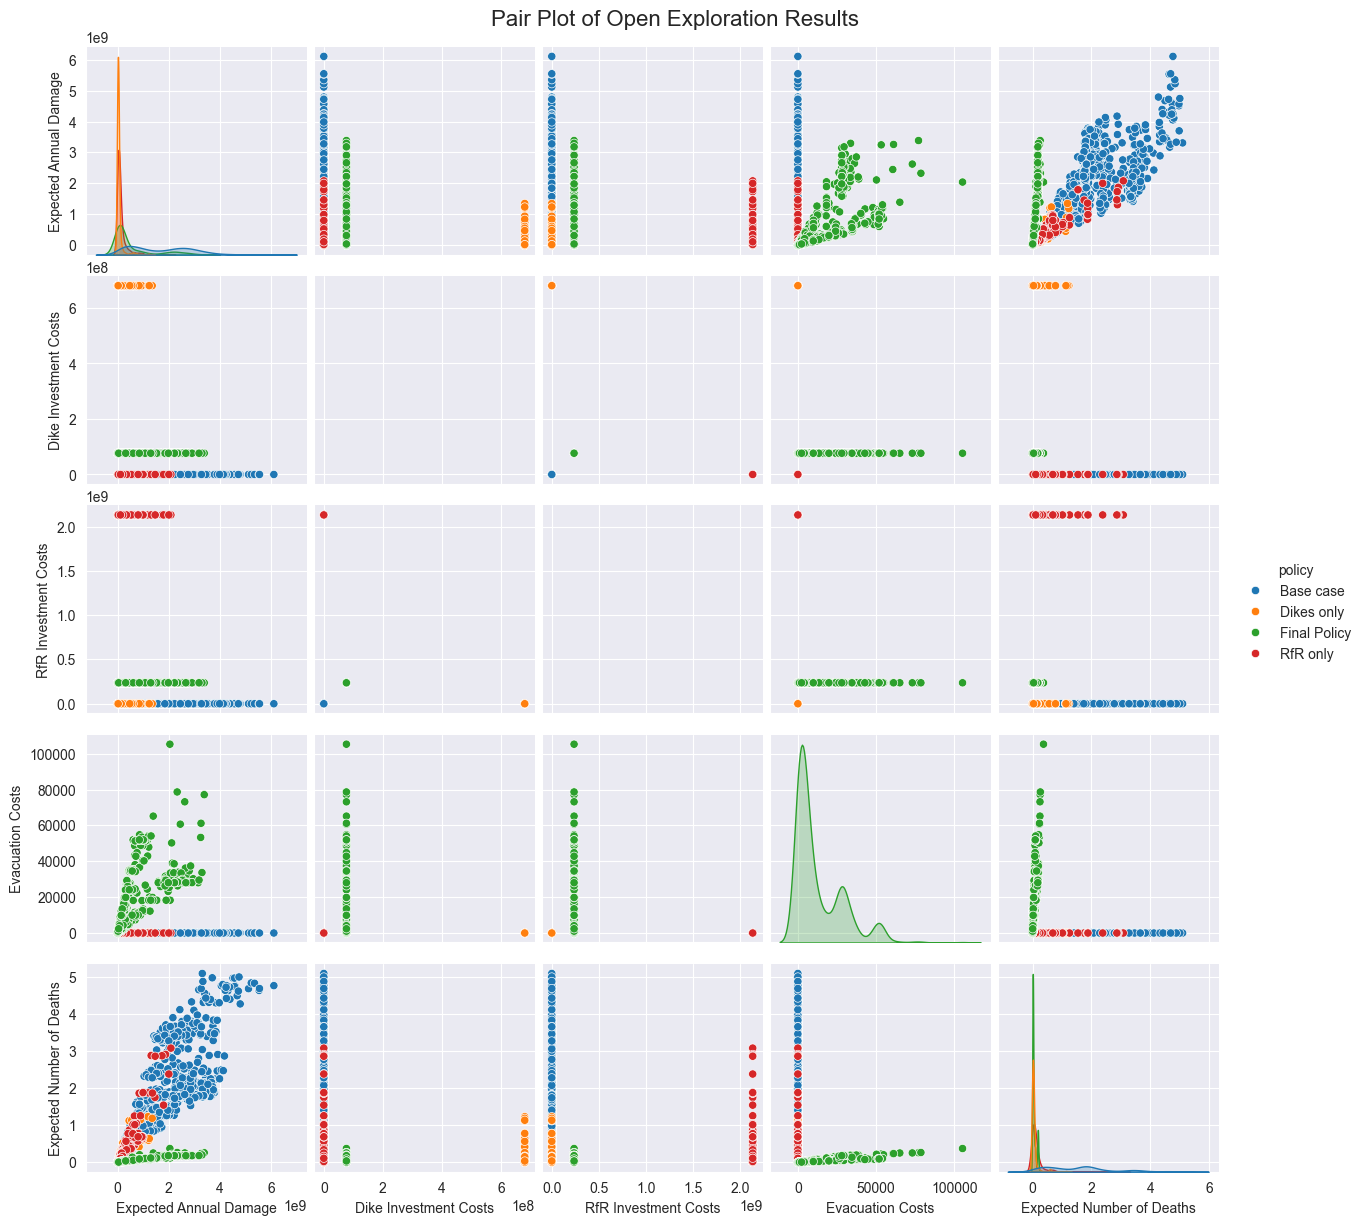

In [16]:
experiments, outcomes = load_results('open_exploration.tar.gz')

policies = experiments['policy']

data = pd.DataFrame.from_dict(outcomes)
data['policy'] = policies

plot = sns.pairplot(data, hue='policy', vars=outcomes.keys(), )
plot.fig.suptitle("Pair Plot of Open Exploration Results", fontsize=16)
plot.fig.subplots_adjust(top=0.95)
plot.savefig("open_exploration.png")
plt.show()

The pair plot shows how the four policies perform over the 1000 scenarios. It is evident that the evacuation costs are highest for the final policy. This can be explained by the warning system that is employed in this policy, other policies don’t include this system. Furthermore, the Environmental Interest Group wants the number of casualties to be as low as possible (ideally 0). The expected number of deaths is highest for the base case in which no action is taken. The expected annual damage is also highest for this policy. Both from an ethical as from an economic point of view it is therefore important that measures are being taken to ensure safety and to reduce damage.

To better understand what possible measures work well a multi-scenario MORDM will be performed in another notebook. The scenarios are based on the open exploration results, making it an adapted version of the multi-scenario MORDM as explained in the introduction of this notebook. In the last bit of code, the values of uncertainties that form these scenarios are extracted and saved.

In [17]:
uncertainties = [unc.name for unc in dike_model.uncertainties]

# Unpack results
experiments, outcomes = load_results('open_exploration.tar.gz')

# Convert 'Expected Number of Deaths' outcome into a DataFrame
deaths = pd.DataFrame(outcomes['Expected Number of Deaths'])

[MainProcess/INFO] results loaded successfully from C:\Users\lmvan\PycharmProjects\EPA141A_Group12_2025\final assignment\open_exploration.tar.gz


In [33]:
# Best case scenario
# Filter for "RfR only" policy
rfr_only_mask = experiments['policy'] == 'RfR only'
deaths_rfr = deaths[rfr_only_mask].copy()

# Add scenario and policy info
deaths_rfr['scenario'] = experiments[rfr_only_mask].index
deaths_rfr['policy'] = experiments[rfr_only_mask]['policy']

# Rename column with expected number of deaths (0)
deaths_rfr.rename(columns={0:'total_deaths'}, inplace=True)

# Find the scenario with the minimum deaths for RfR only
min_idx = deaths_rfr['total_deaths'].idxmin()
min_experiment = experiments.loc[min_idx]

print("Lowest number of deaths (RfR only):")
print(f"Policy: {min_experiment['policy']}, Scenario index: {min_idx}")
print(f"Total deaths: {deaths_rfr.loc[min_idx]['total_deaths']}")
print("\nLever settings for lowest death scenario:")
print(min_experiment[uncertainties])

min_uncertainties = min_experiment[uncertainties]
min_uncertainties_df = pd.DataFrame([min_uncertainties])

# with open("reference_uncertainties_rfr_only.pkl", "wb") as f:
#     pickle.dump(min_uncertainties_df, f)

Lowest number of deaths (RfR only):
Policy: RfR only, Scenario index: 2098
Total deaths: 0.0

Lever settings for lowest death scenario:
discount rate 0                   4.5
discount rate 1                   3.5
discount rate 2                   1.5
A.0_ID flood wave shape           113
A.1_Bmax                   141.175158
A.1_pfail                    0.676314
A.1_Brate                         1.0
A.2_Bmax                   288.594708
A.2_pfail                    0.913399
A.2_Brate                         1.5
A.3_Bmax                    205.96233
A.3_pfail                     0.69333
A.3_Brate                         1.5
A.4_Bmax                   140.241782
A.4_pfail                    0.662488
A.4_Brate                         1.5
A.5_Bmax                   344.506533
A.5_pfail                    0.864793
A.5_Brate                        10.0
Name: 2098, dtype: object


In [35]:
# Worst case scenario
# Filter for "Dike only" policy
dikes_only_mask = experiments['policy'] == 'Dikes only'
deaths_dikes = deaths[dikes_only_mask].copy()

# Add scenario and policy info
deaths_dikes['scenario'] = experiments[dikes_only_mask].index
deaths_dikes['policy'] = experiments[dikes_only_mask]['policy']

# Sum deaths across locations/years (if multi-dimensional)
deaths_dikes['total_deaths'] = deaths_dikes.drop(columns=['scenario', 'policy']).sum(axis=1)

# Rename column with expected number of deaths (0)
deaths_rfr.rename(columns={0:'total_deaths'}, inplace=True)

# Find the scenario with the maximum deaths for dike only
max_idx = deaths_dikes['total_deaths'].idxmax()
max_experiment = experiments.loc[max_idx]

print("Highest number of deaths (Dikes only):")
print(f"Policy: {max_experiment['policy']}, Scenario index: {max_idx}")
print(f"Total deaths: {deaths_dikes.loc[max_idx]['total_deaths']}")
print("\nLever settings for highest death scenario:")
print(max_experiment[uncertainties])

max_uncertainties = max_experiment[uncertainties]
max_uncertainties_df = pd.DataFrame([max_uncertainties])

# with open("reference_uncertainties_dikes_only.pkl", "wb") as f:
#     pickle.dump(max_uncertainties_df, f)

Highest number of deaths (Dikes only):
Policy: Dikes only, Scenario index: 1936
Total deaths: 1.07639502455687

Lever settings for highest death scenario:
discount rate 0                   3.5
discount rate 1                   1.5
discount rate 2                   1.5
A.0_ID flood wave shape            56
A.1_Bmax                    59.581609
A.1_pfail                     0.89347
A.1_Brate                        10.0
A.2_Bmax                    32.743916
A.2_pfail                     0.98342
A.2_Brate                        10.0
A.3_Bmax                   257.255803
A.3_pfail                     0.00035
A.3_Brate                         1.0
A.4_Bmax                   324.002181
A.4_pfail                    0.186928
A.4_Brate                         1.0
A.5_Bmax                   327.282634
A.5_pfail                    0.126277
A.5_Brate                        10.0
Name: 1936, dtype: object
